In [20]:
import numpy as np
import cv2
import matplotlib.pyplot as NguyenThienAn

(np.float64(-0.5), np.float64(554.5), np.float64(278.5), np.float64(-0.5))

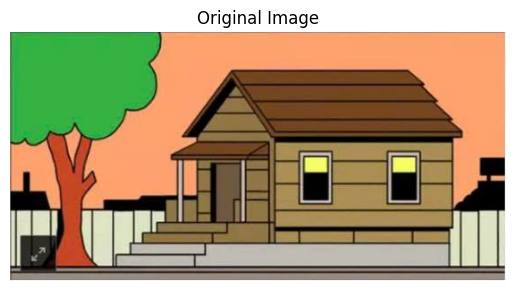

In [2]:
img = cv2.imread('hinh1.jpg')

An.imshow(img[:,:,::-1])
An.title("Original Image")
An.axis("off")

(np.float64(-0.5), np.float64(554.5), np.float64(278.5), np.float64(-0.5))

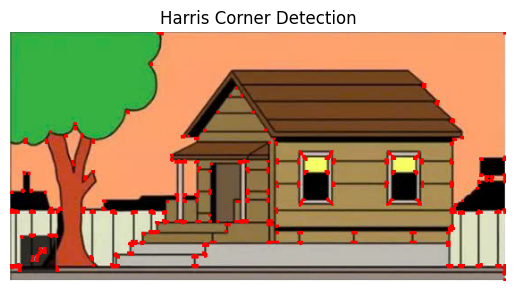

In [3]:
img = cv2.imread('hinh1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

gray = np.float32(gray)

dst = cv2.cornerHarris(gray,2,3,0.04)

dst = cv2.dilate(dst,None)

img[dst>0.01*dst.max()] = [0,0,255]

An.imshow(img[:,:,::-1])
An.title("Harris Corner Detection")
An.axis("off")

(np.float64(-0.5), np.float64(554.5), np.float64(278.5), np.float64(-0.5))

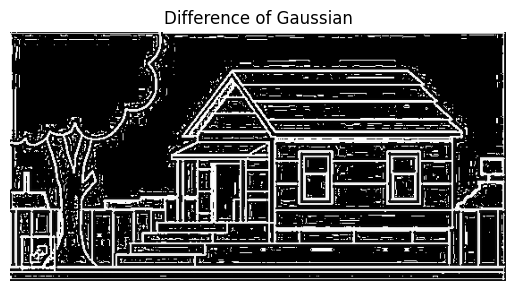

In [4]:
img = cv2.imread('hinh1.jpg',0)

blur1 = cv2.GaussianBlur(img,(5,5),1)
blur2 = cv2.GaussianBlur(img,(5,5),2)

dog = blur1 - blur2

An.imshow(dog, cmap='gray')
An.title("Difference of Gaussian")
An.axis("off")

(np.float64(-0.5), np.float64(554.5), np.float64(278.5), np.float64(-0.5))

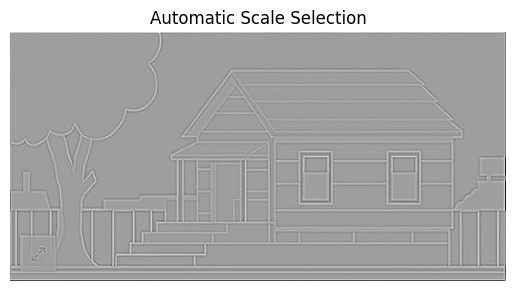

In [5]:
img = cv2.imread('hinh1.jpg',0)

lap = cv2.Laplacian(img,cv2.CV_64F)

An.imshow(lap, cmap='gray')
An.title("Automatic Scale Selection")
An.axis("off")

(np.float64(-0.5), np.float64(554.5), np.float64(278.5), np.float64(-0.5))

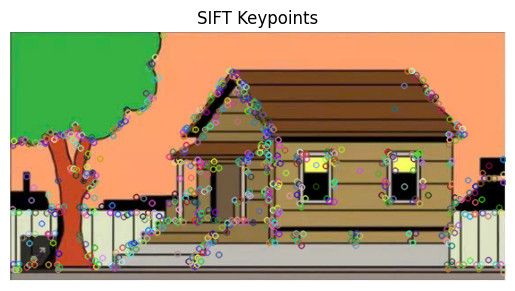

In [6]:
img = cv2.imread('hinh1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()

kp, des = sift.detectAndCompute(gray,None)

img_sift = cv2.drawKeypoints(img,kp,None)

An.imshow(img_sift[:,:,::-1])
An.title("SIFT Keypoints")
An.axis("off")


(np.float64(-0.5), np.float64(554.5), np.float64(278.5), np.float64(-0.5))

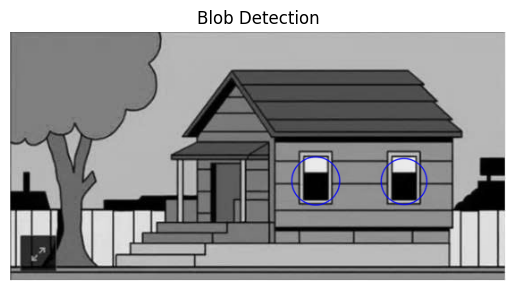

In [7]:
img = cv2.imread('hinh1.jpg',0)

detector = cv2.SimpleBlobDetector_create()

keypoints = detector.detect(img)

img_blob = cv2.drawKeypoints(img,keypoints,np.array([]),(0,0,255),
                             cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

An.imshow(img_blob, cmap='gray')
An.title("Blob Detection")
An.axis("off")

Number of features: 816
Descriptor shape: (816, 128)


In [15]:
img1 = cv2.imread('hinh1.jpg')
img2 = cv2.imread('hinh2.jpg')

stitcher = cv2.Stitcher_create()

status, pano = stitcher.stitch((img1,img2))

if status == cv2.Stitcher_OK:
    An.imshow(pano[:,:,::-1])
    An.title("Panorama")
    An.axis("off")

Text(0.5, 1.0, 'Wide baseline stereo matching')

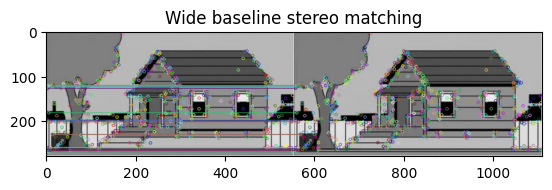

In [17]:
img1 = cv2.imread('hinh1.jpg',0)
img2 = cv2.imread('hinh2.jpg',0)

sift = cv2.SIFT_create()

kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.match(des1,des2)

matches = sorted(matches, key=lambda x:x.distance)

img_match = cv2.drawMatches(img1,kp1,img2,kp2,matches[:20],None)

An.imshow(img_match)
An.title("Wide baseline stereo matching")

In [18]:
sift = cv2.SIFT_create()

img1 = cv2.imread('hinh1.jpg',0)
img2 = cv2.imread('hinh2.jpg',0)

kp1, des1 = sift.detectAndCompute(img1,None)
kp2, des2 = sift.detectAndCompute(img2,None)

bf = cv2.BFMatcher()

matches = bf.knnMatch(des1,des2,k=2)

good = []

for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

print("Number of good matches:",len(good))

Number of good matches: 827


Text(0.5, 1.0, 'SIFT Histogram')

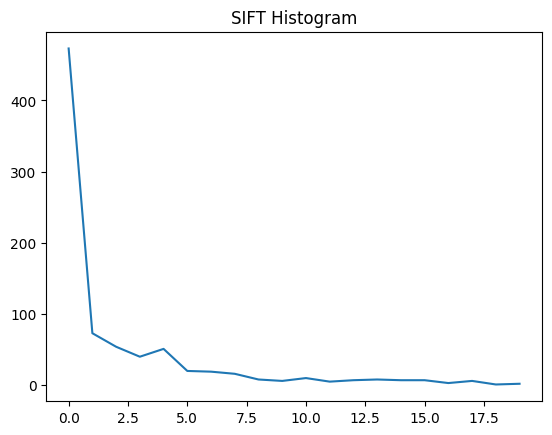

In [19]:
import numpy as np

hist = np.histogram(des[:,0], bins=20)

An.plot(hist[0])
An.title("SIFT Histogram")